In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from PIL import Image
# import wandb

cudnn.benchmark = True
plt.ion()   # interactive mode

# data loader

In [2]:
data_transforms = {
    'train': transforms.Compose([
        #transforms.RandomResizedCrop(size=256, scale=(0.3, 0.7)),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAutocontrast(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        #transforms.RandomResizedCrop(size=256, scale=(0.3, 0.7)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

data_dir = '/home/r10941036/Explainable AI Project/DATA'
print(os.listdir(data_dir+"/train"))
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']} 
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8, shuffle=True, num_workers=4)
               for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

['BCC', 'Hemangioma', 'Psoriasis', 'Nevus', 'Bowen_s disease', 'Melanoma', 'Seborrhoeic keratosis', 'Actinic keratosis', 'Melasma', 'SCC', 'Vitiligo', 'Normal', 'Eczema', 'Solar lentigo']


# Show training image

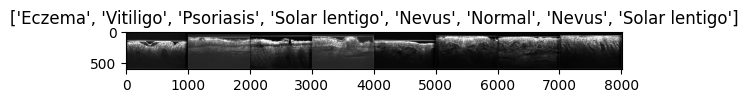

In [3]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

# Model Training Function

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    #wandb.init(project="lesion-classification-project")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    softmax = nn.Softmax(dim=1)
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    #outputs = softmax(outputs).to(dtype = torch.float)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            if(phase=='train'):    
                train_epoch_loss = epoch_loss
                train_epoch_acc = epoch_acc
            else:
                valid_epoch_loss = epoch_loss
                valid_epoch_acc = epoch_acc

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))
            
            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        #visualize_model(model, num_images=6)
        """wandb.log({"train_loss": train_epoch_loss,
                   "train_Acc": train_epoch_acc,
                   "valid_loss": valid_epoch_loss,
                   "vaild_Acc": valid_epoch_acc
                  }, step=epoch)"""
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    #wandb.finish()
    return model

# Model Visualization

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Loading self-supervised pre-trained model architecture

In [23]:
import torchvision.models as models
from exceptions.exceptions import InvalidBackboneError
class ResNetSimCLR(nn.Module):

    def __init__(self, base_model, out_dim):
        super(ResNetSimCLR, self).__init__()
        #self.resnet_dict = {"resnet18": models.resnet18(pretrained=True, num_classes=out_dim),
        #                    "resnet50": models.resnet50(pretrained=False, num_classes=out_dim)}
        model = models.resnet18(pretrained=True)
        num_feat = model.fc.in_features
        model.fc = nn.Linear(num_feat,out_dim)
        self.resnet_dict = {"resnet18": model}
        self.backbone = self._get_basemodel(base_model)
        dim_mlp = self.backbone.fc.in_features
        print(dim_mlp)
        # add mlp projection head
        self.backbone.fc = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.backbone.fc)

    def _get_basemodel(self, model_name):
        try:
            model = self.resnet_dict[model_name]
        except KeyError:
            raise InvalidBackboneError(
                "Invalid backbone architecture. Check the config file and pass one of: resnet18 or resnet50")
        else:
            return model

    def forward(self, x):
        return self.backbone(x)

# Loading model

In [ ]:

# Four class

state_dict = torch.load('simclr_resnet.pkl', map_location=device)
model = ResNetSimCLR('resnet18',32)
model.load_state_dict(state_dict, strict=True)
num_ftrs = model.backbone.fc[2].in_features
model.backbone.fc[2] = nn.Linear(num_ftrs, 4)
model = model.to(device)
criterion = nn.CrossEntropyLoss(weight = torch.tensor([1.,3.,3.,3.]).cuda())

# Seven class
'''
state_dict = torch.load('lesion_FINE_TUNE.pkl', map_location=device)
model = ResNetSimCLR('resnet18',4)
model.load_state_dict(state_dict, strict=True)
num_ftrs = model.backbone.fc[2].in_features
model.backbone.fc[2] = nn.Linear(num_ftrs, 7)
model = model.to(device)
criterion = nn.CrossEntropyLoss(weight = torch.tensor([2561/302,  2561/353, 2561/1021,  2561/225,  2561/172,  2561/338,  2561/150]).cuda())
'''
optimizer_ft = optim.Adam(model.parameters(), lr=0.00005)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

512


# Training model

In [40]:
model = train_model(model, criterion, optimizer_ft, exp_lr_scheduler,num_epochs=20)

Epoch 0/19
----------
train Loss: 0.9434 Acc: 0.5880
val Loss: 0.6868 Acc: 0.7476
Epoch 1/19
----------
train Loss: 0.6124 Acc: 0.7571
val Loss: 0.5429 Acc: 0.7515
Epoch 2/19
----------
train Loss: 0.4277 Acc: 0.8192
val Loss: 0.4416 Acc: 0.8602
Epoch 3/19
----------
train Loss: 0.2946 Acc: 0.8817
val Loss: 0.5019 Acc: 0.8524
Epoch 4/19
----------
train Loss: 0.2540 Acc: 0.8925
val Loss: 0.5097 Acc: 0.7262
Epoch 5/19
----------
train Loss: 0.1526 Acc: 0.9360
val Loss: 0.2955 Acc: 0.8835
Epoch 6/19
----------
train Loss: 0.1225 Acc: 0.9585
val Loss: 0.2713 Acc: 0.9126
Epoch 7/19
----------
train Loss: 0.1190 Acc: 0.9560
val Loss: 0.2758 Acc: 0.9204
Epoch 8/19
----------
train Loss: 0.0948 Acc: 0.9707
val Loss: 0.2905 Acc: 0.8971
Epoch 9/19
----------
train Loss: 0.0801 Acc: 0.9756
val Loss: 0.2653 Acc: 0.9204
Epoch 10/19
----------
train Loss: 0.0796 Acc: 0.9687
val Loss: 0.2599 Acc: 0.9126
Epoch 11/19
----------
train Loss: 0.0762 Acc: 0.9756
val Loss: 0.2650 Acc: 0.9087
Epoch 12/19
--

# Saving model

In [41]:
torch.save(model.state_dict() ,"lesion_FINE_TUNE.pkl") # 0.918447

# Model Validation

In [ ]:
data_transforms_2 = {
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}
column_names = ["image_id", "image", "label", "prediction"]
wandb.init(project="lesion-classification-project")
data_dir = '/home/r10941036/Explainable AI Project/DATA/'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_2[x])
                  for x in ['val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=1, shuffle=False, num_workers=4)
               for x in ['val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['val']}
class_names = image_datasets['val'].classes
print(class_names)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
running_corrects = 0
my_data = []
i = 0
for inputs, labels in dataloaders['val']:
    i+=1
    sub_data =[]
    sub_data.append(i)
    sub_data.append(wandb.Image(inputs))
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    sub_data.append(class_names[labels.item()])
    sub_data.append(class_names[preds.item()])
    my_data.append(sub_data)
    running_corrects += torch.sum(preds == labels.data)
val_table = wandb.Table(data=my_data, columns=column_names)
wandb.log({'my_val_table': val_table})
wandb.finish()
print(running_corrects/dataset_sizes['val'])

# Grad-CAM++

In [16]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
from PIL import Image
from skimage.transform import resize

In [76]:
def crop(img):
    img = np.array(img)
    w, h, c = img.shape
    if(h!=1000):
        img = resize(img[:,:,0],(800,1000))*255
        img_temp = img[:600,:]
        img_final = np.zeros((600,1000,3))
        img_final[:,:,0] = img_temp
        img_final[:,:,1] = img_temp
        img_final[:,:,2] = img_temp
    else:
        img_final = img[:600]
    img = Image.fromarray(np.uint8(img_final))
    return img

In [18]:
transform_test = transforms.Compose([transforms.PILToTensor()])
transform_normalize = transforms.Compose([transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

In [70]:
PATH = "/home/r10941036/Explainable AI Project/DATA/val/Normal/"
path_list = sorted(os.listdir(PATH))
idx = 50
NAME = path_list[idx]
model.eval()
target_layers = [model.backbone.layer4[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers, use_cuda=True)
targets = [ClassifierOutputTarget(2)]
img = Image.open(PATH+NAME).convert('RGB')
test = transform_normalize(transform_test(img)/255).unsqueeze(0)
test = test.to(device)
result = model(test)
sfm = torch.nn.Softmax()
print(torch.max(result,1)[1].item())
rgb_img = np.float32(img)/255
print(rgb_img.shape)
input_tensor = preprocess_image(rgb_img)
grayscale_cam2 = cam(input_tensor=input_tensor,targets=targets)[0,:]
visualization = show_cam_on_image(rgb_img, grayscale_cam2, use_rgb=True)

2
(600, 1000, 3)


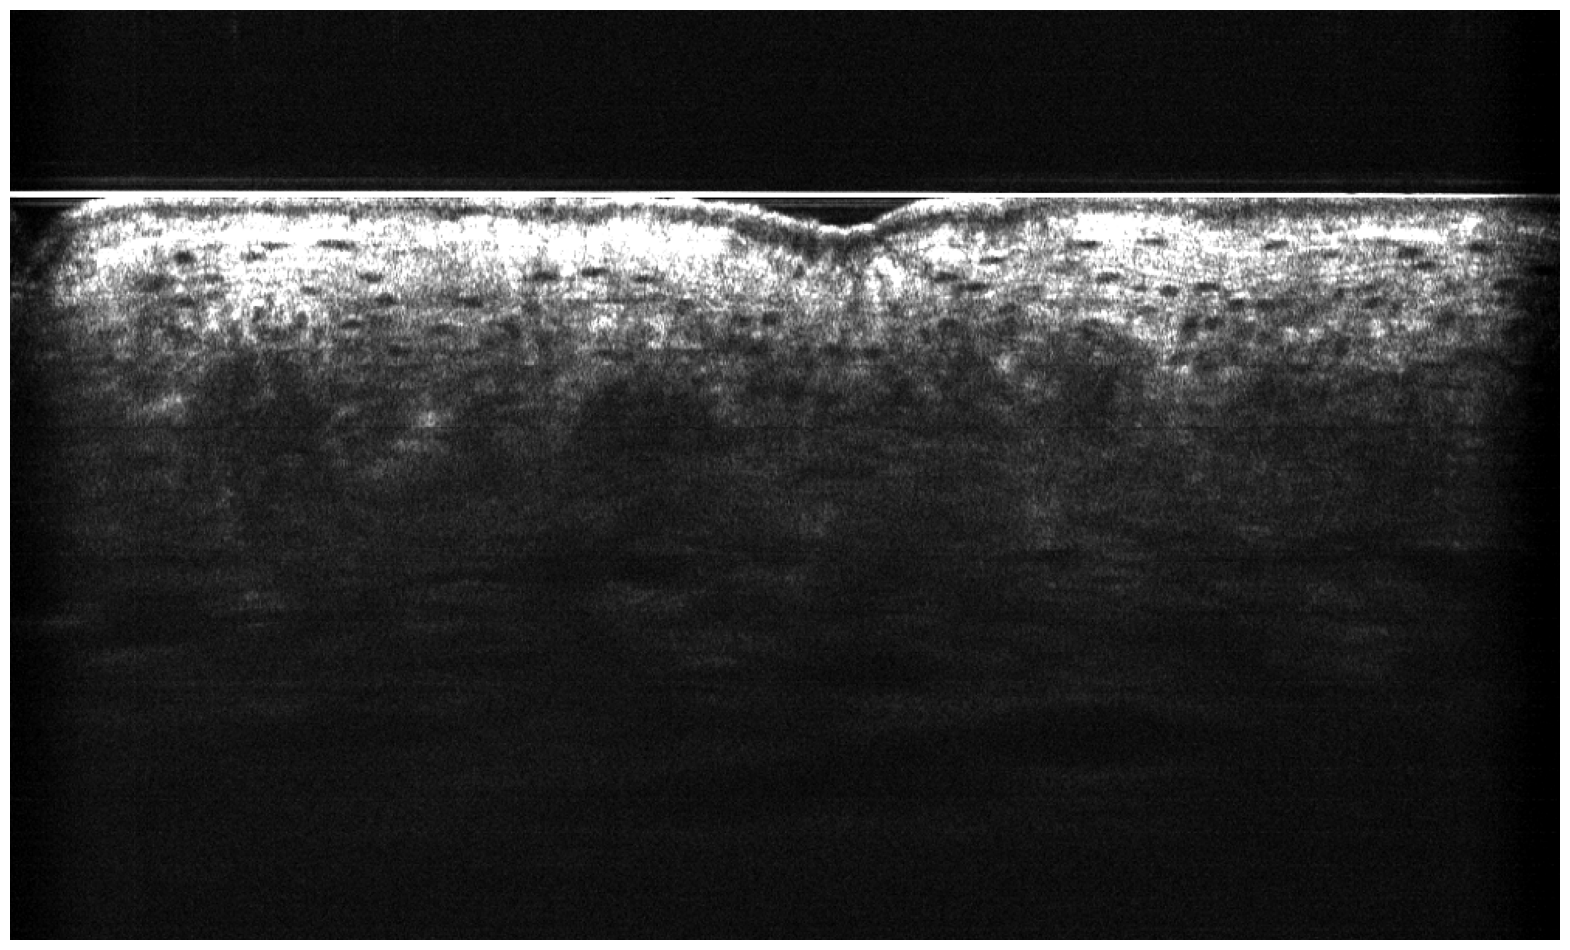

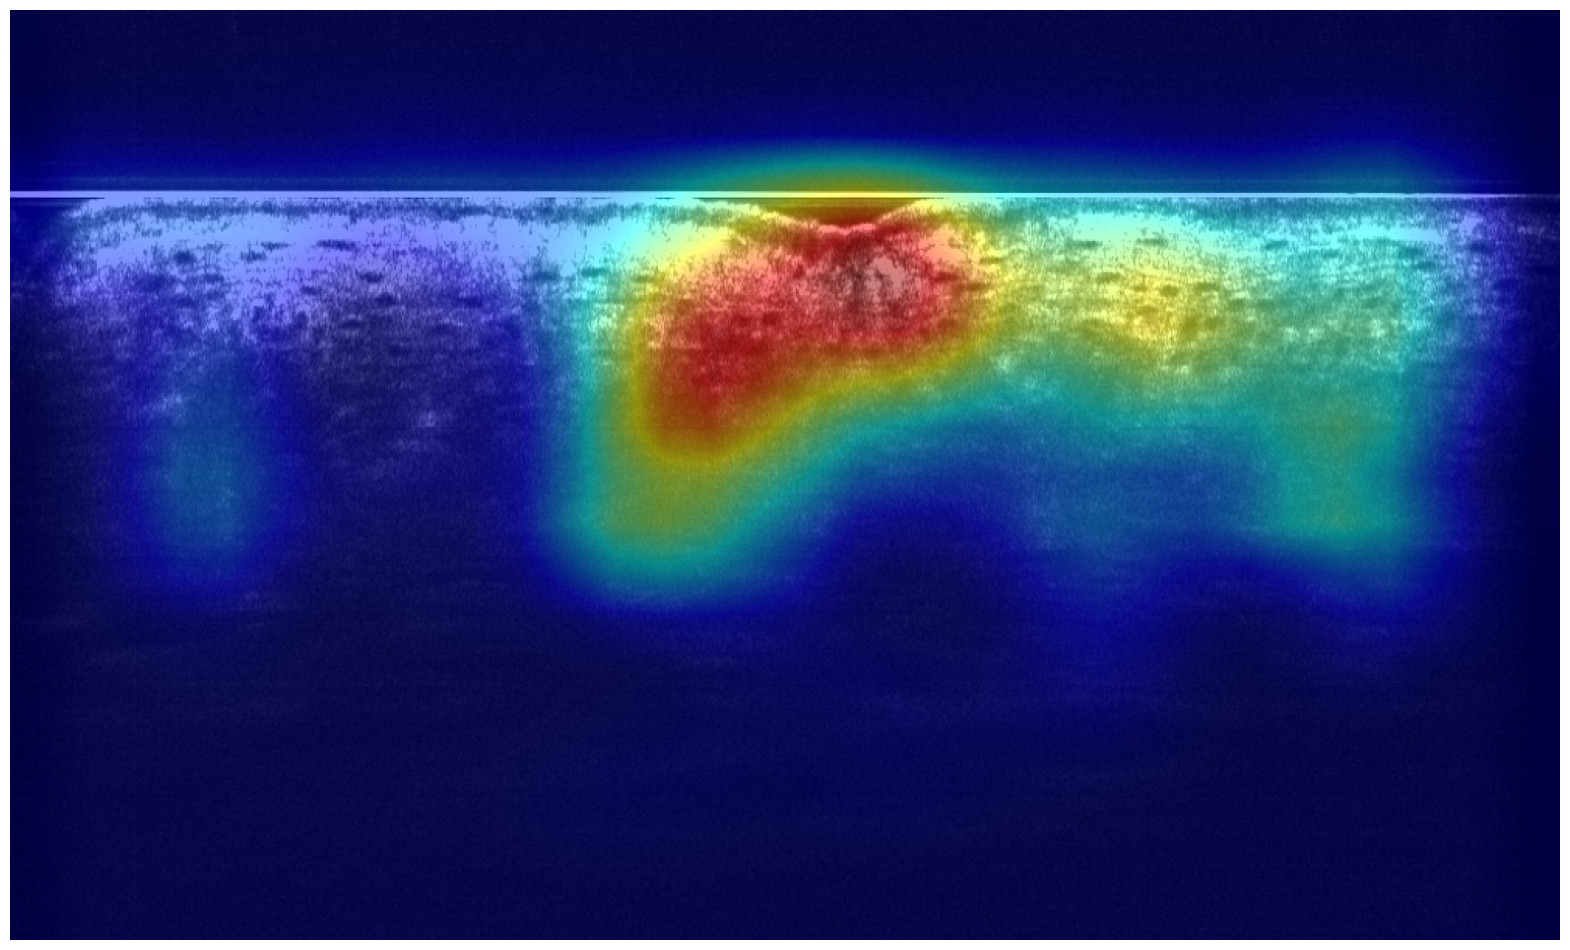

In [71]:
plt.rcParams["figure.figsize"] = (20,20)
plt.imshow(rgb_img,cmap="gray")
plt.axis("off")
plt.show()
plt.rcParams["figure.figsize"] = (20,20)
plt.imshow(visualization,cmap="gray")
plt.axis("off")
plt.show()